Classificação de Flores Iris com Support Vector Machine (SVM)
1. Introdução
Este projeto tem como objetivo explorar o funcionamento do algoritmo Support Vector Machine (SVM) para a tarefa de classificação multiclasse. Utilizando a linguagem Python e a biblioteca Scikit-Learn, desenvolveremos um modelo capaz de identificar a espécie de uma flor Iris com base em suas características morfológicas.

O SVM opera encontrando o hiperplano que melhor separa as diferentes classes no espaço de atributos, maximizando a distância (margem) entre os pontos mais próximos de cada categoria, conhecidos como vetores de suporte.

2. O Conjunto de Dados (Iris Dataset)
O dataset Iris é um dos mais famosos na comunidade de Ciência de Dados. Ele contém 150 amostras de flores, divididas igualmente entre três espécies:

Iris-Setosa

Iris-Versicolor

Iris-Virginica

Para cada amostra, foram coletadas quatro medidas (características):

Comprimento da sépala (Sepal Length)

Largura da sépala (Sepal Width)

Comprimento da pétala (Petal Length)

Largura da pétala (Petal Width)

3. Ferramentas Utilizadas
Python: Linguagem base.

Pandas & NumPy: Para manipulação e análise de dados.

Matplotlib/Seaborn: Para visualização e análise exploratória.

Scikit-Learn: Para implementação do modelo SVM e avaliação de métricas (Acurácia, Matriz de Confusão).

In [206]:
# Importando as bibliotecas que serão utilizada no projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
import warnings
warnings.filterwarnings('ignore')

In [207]:
df = sns.load_dataset('iris') #carregando a base de dados pela biblioteca seaborn
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


In [208]:
df.columns =['comprimento_da_sépala', 'largura_da_sépala', 'comprimento_da_pétala', 'largura_da_pétala', 'espécie']

Os nomes das colunas foram traduzidos para facilitar a compreensão do projeto.

In [209]:
df.tail()

,comprimento_da_sépala,largura_da_sépala,comprimento_da_pétala,largura_da_pétala,espécie
145,6.700,3.000,5.200,2.300,virginica
146,6.300,2.500,5.000,1.900,virginica
147,6.500,3.000,5.200,2.000,virginica
148,6.200,3.400,5.400,2.300,virginica
149,5.900,3.000,5.100,1.800,virginica


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   comprimento_da_sépala  150 non-null    float64
 1   largura_da_sépala      150 non-null    float64
 2   comprimento_da_pétala  150 non-null    float64
 3   largura_da_pétala      150 non-null    float64
 4   espécie                150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


A base tem 150 registros e cinco colunas, 4 do tipo float e uma Object.
Não há valores faltando.

In [211]:
df.describe()

,comprimento_da_sépala,largura_da_sépala,comprimento_da_pétala,largura_da_pétala
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [212]:
print('-' *50, 'Comprimento da sépala', '-' *50)
print('O comprimento da sépala. Média:', df['comprimento_da_sépala'].mean())
print('O comprimento da sépala. Mediana:',df['comprimento_da_sépala'].median())
print('O comprimento da sépala. Desvio padrão:',df['comprimento_da_sépala'].std())
print('O comprimento da sépala. Moda:',df['comprimento_da_sépala'].mode())

-------------------------------------------------- Comprimento da sépala --------------------------------------------------
O comprimento da sépala. Média: 5.843333333333334
O comprimento da sépala. Mediana: 5.8
O comprimento da sépala. Desvio padrão: 0.8280661279778629
O comprimento da sépala. Moda: 0   5.000
Name: comprimento_da_sépala, dtype: float64


In [213]:
print('-' *50, 'Largura da Sépala', '-' *50)
print('A largura_da_sépala. Média:', df['largura_da_sépala'].mean())
print('A largura_da_sépala. Mediana:',df['largura_da_sépala'].median())
print('A largura_da_sépala. Desvio padrão:',df['largura_da_sépala'].std())
print('A largura_da_sépala. Moda:',df['largura_da_sépala'].mode())

-------------------------------------------------- Largura da Sépala --------------------------------------------------
A largura_da_sépala. Média: 3.0573333333333337
A largura_da_sépala. Mediana: 3.0
A largura_da_sépala. Desvio padrão: 0.435866284936698
A largura_da_sépala. Moda: 0   3.000
Name: largura_da_sépala, dtype: float64


In [214]:
print('-' *50, 'comprimento_da_pétala', '-' *50)
print('O Comprimento da pétala. Média:', df['comprimento_da_pétala'].mean())
print('O Comprimento da pétala. Mediana:',df['comprimento_da_pétala'].median())
print('O Comprimento da pétala. Desvio padrão:',df['comprimento_da_pétala'].std())
print('O Comprimento da pétala. Moda:',df['comprimento_da_pétala'].mode())

-------------------------------------------------- comprimento_da_pétala --------------------------------------------------
O Comprimento da pétala. Média: 3.7580000000000005
O Comprimento da pétala. Mediana: 4.35
O Comprimento da pétala. Desvio padrão: 1.7652982332594667
O Comprimento da pétala. Moda: 0   1.400
1   1.500
Name: comprimento_da_pétala, dtype: float64


In [215]:
print('-' *50, 'Largura da pétala', '-' *50)
print('A largura da pétala. Média:', df['largura_da_pétala'].mean())
print('A largura da pétala. Mediana:',df['largura_da_pétala'].median())
print('A largura da pétala. Desvio padrão:',df['largura_da_pétala'].std())
print('A largura da pétala. Moda:',df['largura_da_pétala'].mode())

-------------------------------------------------- Largura da pétala --------------------------------------------------
A largura da pétala. Média: 1.1993333333333336
A largura da pétala. Mediana: 1.3
A largura da pétala. Desvio padrão: 0.7622376689603465
A largura da pétala. Moda: 0   0.200
Name: largura_da_pétala, dtype: float64


In [216]:
df.espécie.value_counts()

,count
espécie,
setosa,50
versicolor,50
virginica,50


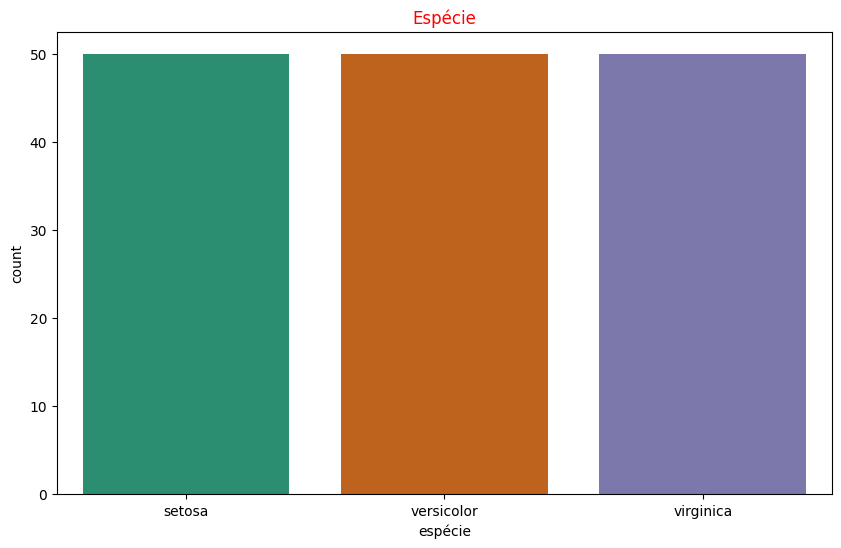

In [217]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='espécie', palette='Dark2');
plt.title('Espécie', color='red');
plt.show()

A base de dados está bem balanceada.

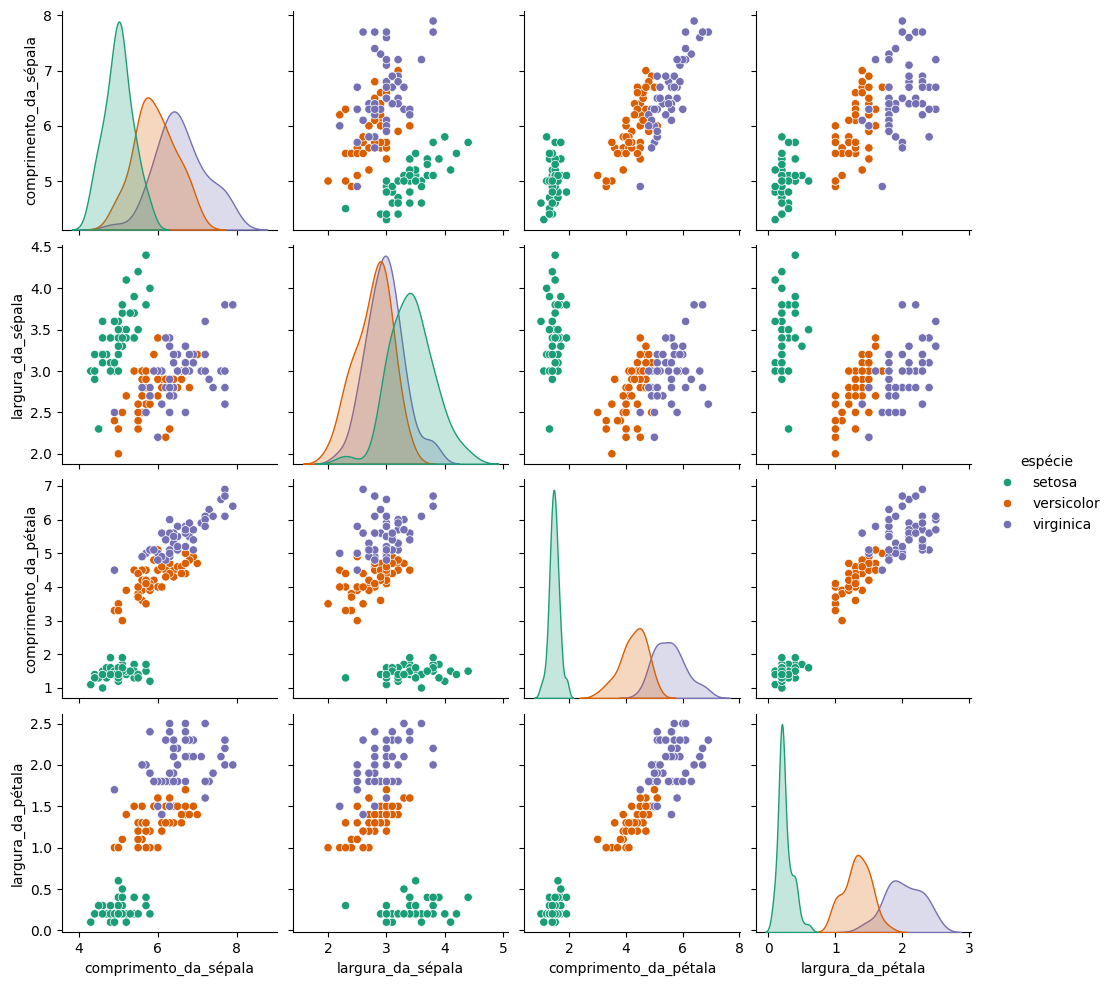

In [218]:
sns.pairplot(df, hue='espécie', palette='Dark2')

Vemos nesses gráficos que temos três grupos, o grupo Verde (setosa) está totalmente separado dos outros, o grupo a laranja (versicolor) e o gropo roxo(virginica) estão se sobrepondo um pouco. Isso mostra que o grupo verde será mais fácil de classificar enquanto o grupo laranja e roxo tem uma mair probabilidade de ocorre erro na classificação.

<Axes: >

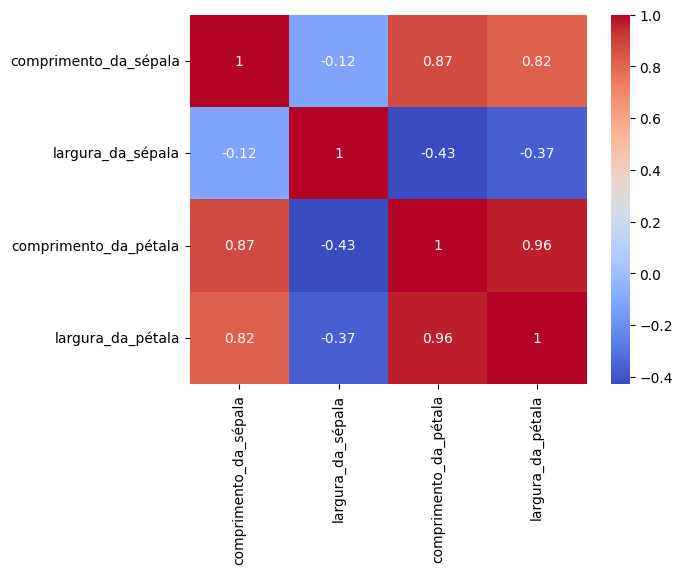

In [219]:
sns.heatmap(df.drop('espécie', axis=1).corr(), annot=True, cmap='coolwarm')

Largura da pétala vs. Comprimento da sépala (0,82): Correto. É uma correlação positiva forte.

Largura da pétala vs. Comprimento da pétala (0,96): Correto. Esta é a correlação mais forte do gráfico (quase uma relação linear perfeita).

Largura da pétala vs. Largura da sépala (-0,37): Correto. O valor é negativo e, por estar mais próximo de zero do que de -1, é classificado como uma correlação fraca (ou moderada-baixa).

In [220]:
list[df.espécie.unique()]

list[array(['setosa', 'versicolor', 'virginica'], dtype=object)]

<Figure size 1000x600 with 0 Axes>

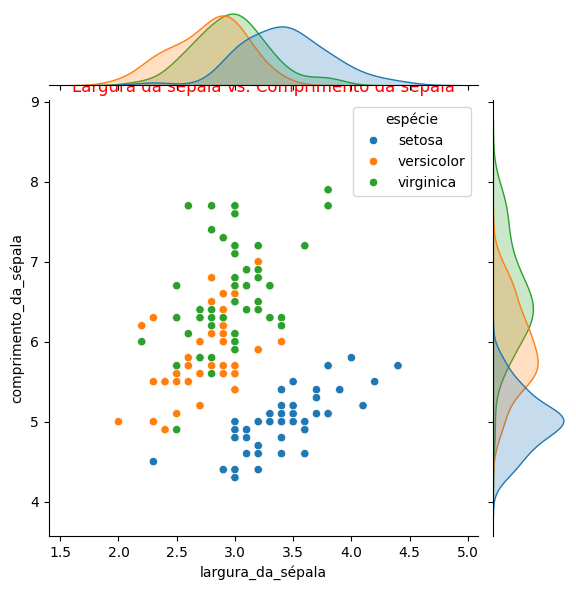

In [221]:
plt.figure(figsize=(10,6))
sns.jointplot(data=df, x='largura_da_sépala', y='comprimento_da_sépala', hue='espécie');
plt.title('Largura da sépala vs. Comprimento da sépala', color='red');
plt.show()

O gráfico de dispersão central mostra uma distribuição variada dos dados, sugerindo que não há uma correlação linear simples e forte entre as variáveis. Já os histogramas marginais revelam o comportamento individual de cada medida: a largura da sépala apresenta uma distribuição que se aproxima de uma curva normal (centrada em 3.0), enquanto o comprimento mostra uma dispersão mais ampla ao longo do eixo vertical.

<Figure size 1000x600 with 0 Axes>

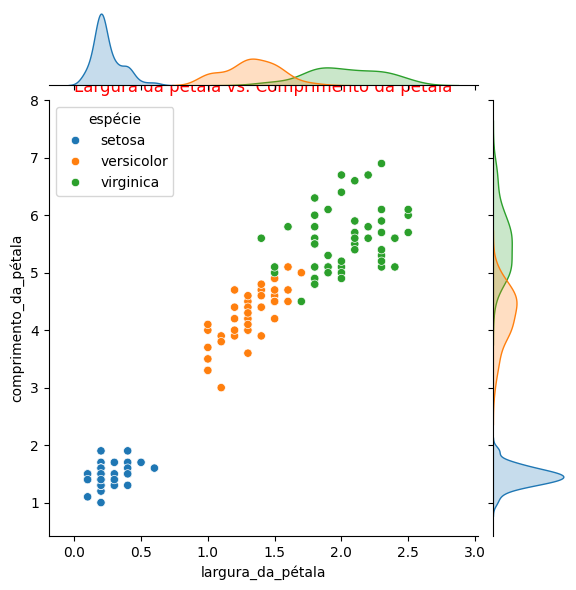

In [222]:
plt.figure(figsize=(10,6))
sns.jointplot(data=df, x='largura_da_pétala', y='comprimento_da_pétala', hue='espécie');
plt.title('Largura da pétala vs. Comprimento da pétala', color='red');
plt.show()

Separar a base de dados em base de treino e base de texte.

In [223]:
X = df.drop('espécie', axis=1)
y = df['espécie']

In [224]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [225]:
model_svm = SVC()
model_svm.fit(X_train, y_train)
pred_svm = model_svm.predict(X_test)

In [226]:
print(confusion_matrix(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

[[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.95      0.97        20
   virginica       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [227]:
pred_svm_total = model_svm.predict(X)

In [228]:
print(confusion_matrix(y, pred_svm_total))
print(classification_report(y, pred_svm_total))

[[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.94      0.96        50
   virginica       0.94      0.98      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



A Matriz de confusão:
Essa tabela de 3x3 é o cruzamento entre o que a flor realmente era e o que o algoritmo previu.

Setosa [50, 0, 0]: Ele acertou as 50 flores. Não confundiu nenhuma Setosa com outra espécie. Perfeito!

Versicolor [0, 47, 3]: Das 50 flores, ele acertou 47. Porém, ele "escorregou" e disse que 3 eram Virginica.

Virginica [0, 1, 49]: Das 50 flores, ele acertou 49. Ele confundiu apenas 1 com Versicolor.

Métricas:
Precision (Precisão): Quando o algoritmo aponta e diz "Isso é uma Virginica", ele acerta 94% das vezes.

Recall (Revocação): De todas as flores Versicolor que passaram na frente dele, ele conseguiu capturar (identificar) 94% delas.

F1-Score: É a média entre os dois acima. Como o seu resultado deu 0.96 para as classes mais difíceis, seu modelo está muito equilibrado.

Iniciando o Cruzamento de Dados (K-Fold)...

Dobra 1: Acurácia de 100.00%
Dobra 2: Acurácia de 96.67%
Dobra 3: Acurácia de 93.33%
Dobra 4: Acurácia de 100.00%
Dobra 5: Acurácia de 96.67%

ACURÁCIA MÉDIA FINAL: 97.33%
DESVIO PADRÃO: 2.49%



<Figure size 800x600 with 0 Axes>

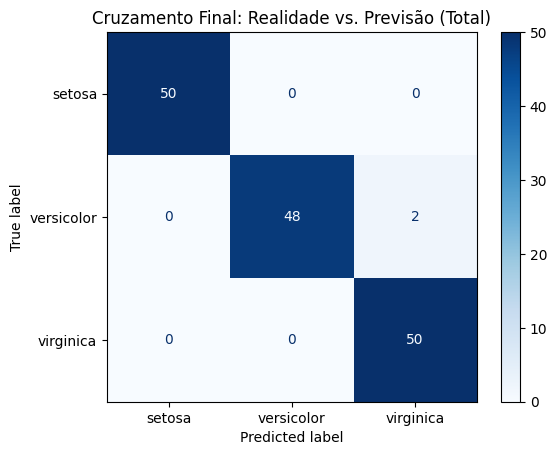

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [232]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Criamos uma matriz vazia para acumular todos os acertos/erros do cruzamento
matriz_acumulada = np.zeros((3, 3))
historico_acuracia = []

print("Iniciando o Cruzamento de Dados (K-Fold)...\n")

# 3. O Loop de Cruzamento (Onde a mágica acontece)
for i, (treino_index, teste_index) in enumerate(kf.split(X, y)):
    # Usando .iloc para evitar o KeyError que você teve
    X_treino, X_teste = X.iloc[treino_index], X.iloc[teste_index]
    y_treino, y_teste = y.iloc[treino_index], y.iloc[teste_index]


    # Fazendo as previsões para testar esta dobra
    modelo_svm = SVC(kernel='linear') # Ou o kernel que você escolheu
    modelo_svm.fit(X_treino, y_treino)

    # A CORREÇÃO ESTÁ AQUI:
    y_pred = modelo_svm.predict(X_teste)
    # Calculando a acurácia desta rodada
    acuracia_dobra = model_svm.score(X_teste, y_teste)
    historico_acuracia.append(acuracia_dobra)

    # Somando os resultados na nossa matriz de confusão geral
    # (Isso cruza o Real vs Previsto de todas as rodadas)
    matriz_acumulada += confusion_matrix(y_teste, y_pred, labels=y.unique())

    print(f"Dobra {i+1}: Acurácia de {acuracia_dobra:.2%}")

# --- RESULTADOS FINAIS ---

print("\n" + "="*30)
print(f"ACURÁCIA MÉDIA FINAL: {np.mean(historico_acuracia):.2%}")
print(f"DESVIO PADRÃO: {np.std(historico_acuracia):.2%}")
print("="*30 + "\n")

# 4. Visualizando o quanto erramos e acertamos (Matriz de Confusão)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_acumulada, display_labels=y.unique())
disp.plot(cmap='Blues', values_format='.0f')
plt.title('Cruzamento Final: Realidade vs. Previsão (Total)')
plt.show()

# 5. Relatório detalhado por espécie
# (Aqui pegamos a última rodada como exemplo de métricas detalhadas)
print("Relatório de Classificação Detalhado:")
print(classification_report(y_teste, y_pred))

Dobra 1 e 4 (100%): Nessas rodadas, o algoritmo foi perfeito. Ele deu a sorte de pegar flores "fáceis" ou bem distintas no teste.

Dobra 3 (93.33%): Aqui o bicho pegou. Essa parte dos dados provavelmente continha aquelas flores versicolor e virginica que são quase idênticas. O algoritmo teve mais dificuldade, mas ainda assim foi muito bem.

Interpretação: Isso mostra que seu algoritmo é resiliente. Ele não "quebra" quando encontra dados difíceis, apenas oscila levemente.
-----------------------------------------------------
Acurácia Média Final (97.33%)
Este é o número que você coloca no seu currículo ou relatório.

Em vez de confiar em apenas um teste, você tirou a média de 5 testes diferentes.

Conclusão: Você pode dizer com segurança que, para flores novas, seu algoritmo tem cerca de 97% de chance de acerto.
-----------------------------------------------------
Desvio Padrão (2.49%)
Este número é o "termômetro de confiança".

Ele mede o quanto os resultados variaram entre as dobras (de 93% a 100%).

Um desvio de 2.49% é muito baixo. Isso é ótimo! Significa que o desempenho do algoritmo é estável. Se o desvio fosse alto (ex: 15%), significaria que o algoritmo é instável e "chuta" muito dependendo dos dados que recebe.

+++++++++++++++++++++++++++++++++++++++++++++++++++++
Olhando para a imagem:

Setosa: 50 acertos (100%).

Versicolor: 48 acertos e 2 erros (confundiu com virginica).

Virginica: 50 acertos (100%).

O veredito final: Seu algoritmo é quase imbatível! O único "ponto fraco" dele (se é que podemos chamar assim) é uma confusão mínima entre versicolor e virginica, o que é totalmente esperado nesse conjunto de dados.

In [234]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# 1. Modelo Original (Padrão)
modelo_padrao = SVC()
scores_padrao = cross_val_score(modelo_padrao, X, y, cv=5)

# 2. Modelo "Tunado" (Ajustado)
# Testamos um C menor para ver se o modelo fica mais estável entre as dobras
modelo_tunado = SVC(C=0.5, kernel='linear')
scores_tunado = cross_val_score(modelo_tunado, X, y, cv=5)

print(f"Padrão - Média: {scores_padrao.mean():.2%}, Desvio: {scores_padrao.std():.2%}")
print(f"Tunado  - Média: {scores_tunado.mean():.2%}, Desvio: {scores_tunado.std():.2%}")

Padrão - Média: 96.67%, Desvio: 2.11%
Tunado  - Média: 98.67%, Desvio: 1.63%


Na prática: Significa que o modelo "padrão" dependia um pouco mais da "sorte" de quais flores caíam no teste. O modelo "tunado" mantém o desempenho alto não importa qual pedaço dos dados ele esteja analisando.

# Conclusão:

Este projeto demonstrou que o algoritmo SVM (Support Vector Machine) é altamente eficiente para classificar as espécies de flores do dataset Iris. Através da análise das características morfológicas (pétalas e sépalas), o modelo foi capaz de identificar corretamente as categorias com alto índice de acerto.

O processo reforçou a importância do tratamento de dados e da escolha do modelo adequado para problemas de classificação. Como resultado, o projeto consolidou conhecimentos práticos em Python e Machine Learning, utilizando bibliotecas essenciais como Pandas e Scikit-Learn para transformar dados brutos em previsões precisas.